# Анализ лояльности пользователей Яндекс Афиши

In [ ]:
фыв

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install sqlalchemy
!pip install psycopg2
!pip install phik
import phik
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
db_config = {'user': 'praktikum_student',
             'pwd': 'Sdf4$2;d-d30pp',
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432,
             'db': 'data-analyst-afisha'
             }
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)
engine = create_engine(connection_string)

In [3]:
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    (created_dt_msk::date - LAG(created_dt_msk::date) OVER (PARTITION BY user_id ORDER BY created_dt_msk)) AS days_since_prev,
    event_id,
    event_name_code AS event_name,
    event_type_main,
    service_name,
    region_name,
    city_name
FROM afisha.purchases p
JOIN afisha.events AS e USING (event_id)
JOIN afisha.city AS c USING (city_id)
JOIN afisha.regions AS r USING (region_id)
WHERE (device_type_canonical = 'mobile' OR device_type_canonical = 'desktop') 
  AND event_type_main != 'фильм'
ORDER BY user_id ASC
'''
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [4]:
df.info()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
13895,0a7b35289893d3d,mobile,6277138,2024-10-13,2024-10-13 13:49:02,rub,14.33,3,NaN,564066,1be13306-cb02-4c88-9bda-1de51be020e9,концерты,Билеты без проблем,Каменноозёрный край,Ордакент
219235,b5612b728f32311,mobile,1712770,2024-10-25,2024-10-25 19:57:55,rub,798.87,3,4.0,511247,4ae26ffc-7577-43cb-bb09-503de755b396,другое,Билеты в руки,Озернинский край,Родниковецк
44233,1b14cf15637900f,mobile,226259,2024-09-30,2024-09-30 21:28:59,rub,636.27,2,NaN,495762,c7728284-b744-491f-af44-97554cc25794,другое,Билеты в руки,Медовская область,Радужсвет
46334,1c2a2133e1df1b4,mobile,8009366,2024-09-08,2024-09-08 22:12:08,rub,329.70,4,0.0,549962,a8dc8a67-b1a2-4cf3-890c-48a4731acb45,театр,Билеты в руки,Сосновская область,Солчелуг
75558,37ad3d90c0e0e9c,mobile,999254,2024-06-01,2024-06-01 13:36:11,rub,512.17,3,NaN,520235,d23aa983-cd4a-459f-9127-e04a14b08339,концерты,Быстрый кассир,Каменевский регион,Глиногорск


В ходе выполнения этапа была успешно произведена выгрузка данных из базы и сформирован датафрейм, содержащий информацию о пользователях, заказах и характеристиках мероприятий.

Первичный анализ показал, что структура данных соответствует поставленной задаче: присутствуют все необходимые поля для анализа поведения пользователей и оценки их лояльности. Объём выборки является достаточным для проведения статистически значимых исследований.

Было выявлено, что данные в целом корректны, однако требуют предобработки: необходимо привести типы данных к нужному формату и подготовить числовые показатели для дальнейшего анализа.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [5]:
tenge_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
tenge_rate['data'] = pd.to_datetime(tenge_rate['data'])
df = df.merge(tenge_rate, left_on = 'order_dt', right_on = 'data')
df['revenue_rub'] = np.where(
    df['currency_code'] == 'kzt',
    round (df['revenue'] * (df['curs'] / df['nominal']),2),
    df['revenue'])
df = df.drop(columns=['data', 'nominal', 'curs', 'cdx'])

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

### Проверяем пропуски

In [6]:
round(df.isna().sum() / len(df) * 100,2)

user_id                  0.00
device_type_canonical    0.00
order_id                 0.00
order_dt                 0.00
order_ts                 0.00
currency_code            0.00
revenue                  0.00
tickets_count            0.00
days_since_prev          7.55
event_id                 0.00
event_name               0.00
event_type_main          0.00
service_name             0.00
region_name              0.00
city_name                0.00
revenue_rub              0.00
dtype: float64

### Сокращаем битность

In [7]:
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['revenue_rub'] = pd.to_numeric(df['revenue_rub'], downcast='float')

### Проверка распределения

In [8]:
df.describe(percentiles=[0.99]).T.round(2)

,count,mean,min,50%,99%,max,std
order_id,290611.0,4326225.491537,1.0,4326366.0,8566888.1,8653108.0,2497550.533496
order_dt,290611,2024-09-01 22:36:38.741272576,2024-06-01 00:00:00,2024-09-12 00:00:00,2024-10-31 00:00:00,2024-10-31 00:00:00,NaN
order_ts,290611,2024-09-02 13:31:19.397730560,2024-06-01 00:00:42,2024-09-12 14:02:10,2024-10-31 21:32:27.800000,2024-10-31 23:59:54,NaN
revenue,290611.0,625.58436,-90.76,356.01,4003.133,81174.54,1227.693064
tickets_count,290611.0,2.754311,1.0,3.0,6.0,57.0,1.17062
days_since_prev,268678.0,3.222381,0.0,0.0,63.0,148.0,11.343196
event_id,290611.0,438019.834992,4436.0,498275.0,589623.0,592325.0,147423.078841
revenue_rub,290611.0,555.571989,-90.76,351.14,2628.42,81174.54,875.49817


**Есть выбросы в столбце **`revenue_rub`** отфильтруем их из датафрейма и создадим new_df**

In [9]:
outliers_revenue_rub = df['revenue_rub'].quantile(0.99)
new_df = df.loc[df['revenue_rub'] < outliers_revenue_rub]
print(f'Отфильтровано кол-во: {len(df) - len(new_df)} строк')
print(f'Отфильтровано в процентах: {round(((len(df) - len(new_df)) / len(df))*100,2)} %')
print(f'Новое кол-во строк: {len(new_df)}')

Отфильтровано кол-во: 3007 строк
Отфильтровано в процентах: 1.03 %
Новое кол-во строк: 287604


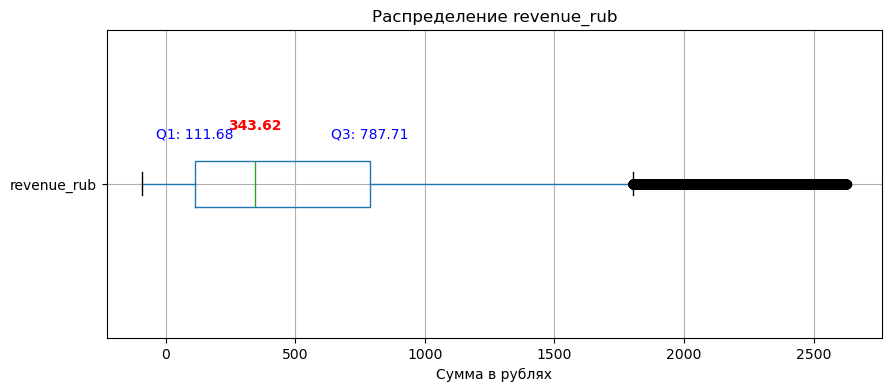

In [10]:
boxplot = new_df.boxplot(column='revenue_rub', figsize=(10, 4), vert=False, return_type='dict')
plt.title('Распределение revenue_rub')
plt.xlabel('Сумма в рублях')
for line in boxplot['medians']:
    x, y = line.get_xydata()[1]
    plt.text(x, y + 0.1, f'{x:.2f}', horizontalalignment='center', fontweight='bold', color='red')
for line in boxplot['boxes']:
    x_coords = line.get_xdata()
    q1, q3 = x_coords[0], x_coords[2]
    plt.text(q1, 1.15, f'Q1: {q1:.2f}', horizontalalignment='center', color='blue')
    plt.text(q3, 1.15, f'Q3: {q3:.2f}', horizontalalignment='center', color='blue')
plt.show()

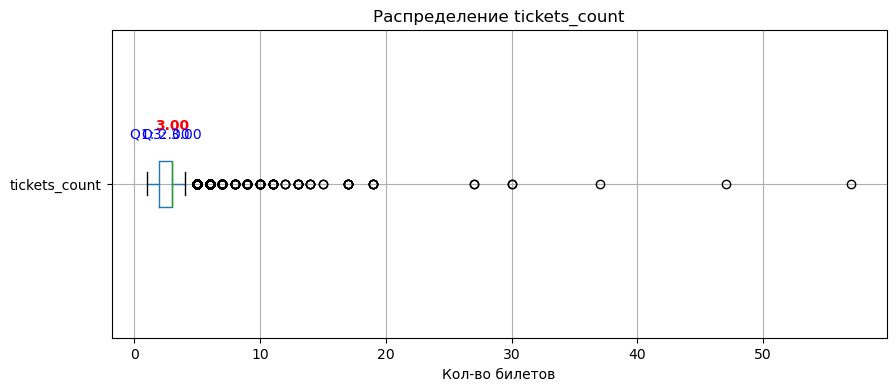

In [11]:
boxplot = new_df.boxplot(column='tickets_count', figsize=(10, 4), vert=False, return_type='dict')
plt.title('Распределение tickets_count')
plt.xlabel('Кол-во билетов')
for line in boxplot['medians']:
    x, y = line.get_xydata()[1]
    plt.text(x, y + 0.1, f'{x:.2f}', horizontalalignment='center', fontweight='bold', color='red')
for line in boxplot['boxes']:
    x_coords = line.get_xdata()
    q1, q3 = x_coords[0], x_coords[2]
    plt.text(q1, 1.15, f'Q1: {q1:.2f}', horizontalalignment='center', color='blue')
    plt.text(q3, 1.15, f'Q3: {q3:.2f}', horizontalalignment='center', color='blue')
plt.show()

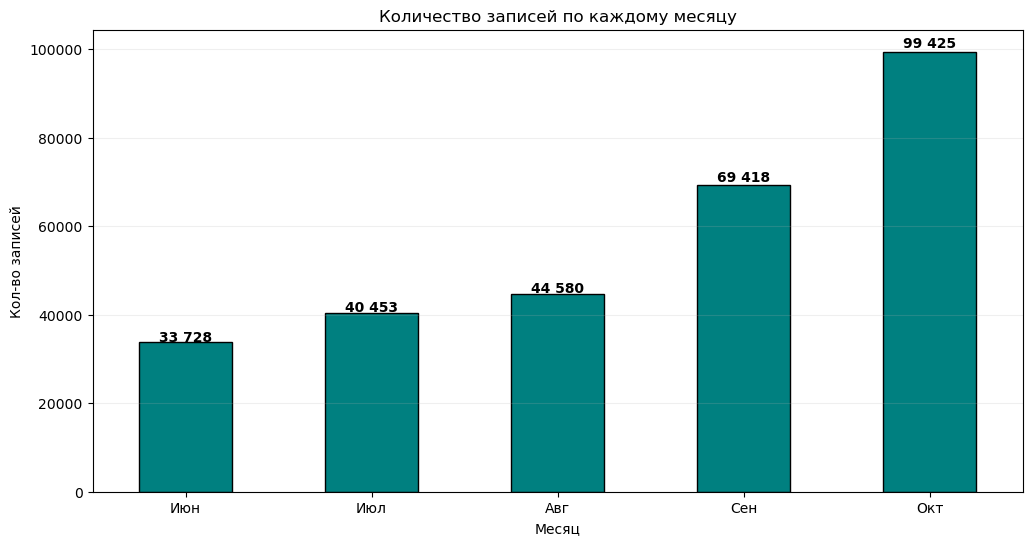

In [12]:
new_df = new_df.copy()
new_df['month'] = new_df['order_dt'].dt.month
month_counts = new_df['month'].value_counts().sort_index()
month_names = ['', 'Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
plt.figure(figsize=(12, 6))
ax = month_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Количество записей по каждому месяцу')
plt.xlabel('Месяц')
plt.ylabel('Кол-во записей')
plt.xticks(
    ticks=range(len(month_counts)), 
    labels=[month_names[int(i)] for i in month_counts.index], 
    rotation=0
)
for i, v in enumerate(month_counts):
    ax.text(i, v + (v * 0.01), f'{v:,}'.replace(',', ' '), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.2)
plt.show()

На этапе предобработки были выполнены ключевые шаги по очистке и подготовке данных:

- выручка приведена к единой валюте (рубли), что обеспечило сопоставимость финансовых показателей;
- проведён анализ категориальных признаков и устранены возможные некорректные значения;
- исследованы распределения числовых признаков.

Особое внимание уделено выбросам: экстремальные значения выручки были отфильтрованы по 99-му перцентилю. Это позволило исключить аномальные заказы, искажающие статистику, и сосредоточиться на типичном поведении пользователей.

В результате был сформирован очищенный и консистентный датасет, пригодный для дальнейшего анализа.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [13]:
df_sort = new_df.sort_values(by = ['user_id','order_dt'], ascending = True)
group = df_sort.groupby('user_id').agg({
    'order_dt': ['min','max'],
    'device_type_canonical': 'first',
    'region_name': 'first',
    'service_name': 'first',
    'event_type_main': 'first',
    'user_id': 'count',
    'revenue_rub': 'mean',
    'tickets_count': 'mean',
    'days_since_prev': 'mean'})
group.columns = ['first_order',
                 'last_order',
                 'device',
                 'first_region',
                 'first_service',
                 'first_event_type',
                 'orders_count',
                 'avg_revenue',
                 'avg_tickets',
                 'avg_gap']
group['is_5'] = np.where(group['orders_count'] >= 5, "is_five", None)
group['is_2'] = np.where(group['orders_count'] >= 2, "is_two", None)
group.head(5)

,first_order,last_order,device,first_region,first_service,first_event_type,orders_count,avg_revenue,avg_tickets,avg_gap,is_5,is_2
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,None,None
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,None,is_two
000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,None,is_two
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,None,None
000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,None,is_two


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [14]:
print (f""" Общее число пользователей: {len(group)}
 Средняя выручка с одного заказа: {round(group['avg_revenue'].mean(),2)}
 Доля пользователей, совершивших 2 и более заказа: {group['is_2'].count()}
 Доля пользователей, совершивших 5 и более заказов: {group['is_5'].count()}""")

group[['orders_count', 'avg_tickets', 'avg_gap']].describe(percentiles = [0.95, 0.99])

 Общее число пользователей: 21848
 Средняя выручка с одного заказа: 543.39
 Доля пользователей, совершивших 2 и более заказа: 13483
 Доля пользователей, совершивших 5 и более заказов: 6337


,orders_count,avg_tickets,avg_gap
count,21848.000000,21848.000000,13518.000000
mean,13.163859,2.742918,15.848565
std,121.624128,0.913389,22.314655
min,1.000000,1.000000,0.000000
50%,2.000000,2.750000,8.000000
95%,31.650000,4.000000,61.500000
99%,152.000000,5.000000,112.000000
max,10175.000000,11.000000,148.000000


Выбор 95-го перцентиля обусловлен необходимостью отсечь экстремальные аномалии (например, аккаунты с 10 000+ заказов), которые критически завышают средние показатели и искажают стандартное отклонение. Данный порог позволяет сфокусироваться на поведении типичных лояльных клиентов, совершающих до 31 заказа, что выглядит реалистично в рамках бизнес-логики сервиса. Удаление всего 5% наиболее активных пользователей делает статистические выводы более устойчивыми и применимыми к основной массе аудитории.

In [15]:
group_corr = group.loc[group['orders_count'] < group['orders_count'].quantile(0.95)]

In [16]:
print (f""" После корректировки удалено: {len(group) - len(group_corr)} строк
 После корректировки удалено в процентах: {round(((len(group) - len(group_corr)) / len(group))*100,2)} %
 Общее число пользователей: {len(group_corr)}
 Средняя выручка с одного заказа: {round(group_corr['avg_revenue'].mean(),2)}
 Доля пользователей, совершивших 2 и более заказа: {group_corr['is_2'].count()}
 Доля пользователей, совершивших 5 и более заказов: {group_corr['is_5'].count()}""")

group_corr[['orders_count', 'avg_tickets', 'avg_gap']].describe()

 После корректировки удалено: 1093 строк
 После корректировки удалено в процентах: 5.0 %
 Общее число пользователей: 20755
 Средняя выручка с одного заказа: 545.7
 Доля пользователей, совершивших 2 и более заказа: 12390
 Доля пользователей, совершивших 5 и более заказов: 5244


,orders_count,avg_tickets,avg_gap
count,20755.000000,20755.000000,12425.000000
mean,4.048518,2.743395,17.052515
std,5.111148,0.934862,22.884529
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,9.461538
75%,5.000000,3.150000,22.000000
max,31.000000,11.000000,148.000000


В рамках данного этапа был сформирован агрегированный профиль пользователя, включающий поведенческие и транзакционные характеристики.

Анализ показал, что:

- значительная доля пользователей совершает только один заказ;
- доля пользователей с повторными заказами существенно ниже, а доля высоколояльных пользователей (5+ заказов) ещё меньше;
- распределения по количеству заказов и другим метрикам имеют выбросы.

Для повышения устойчивости анализа было принято решение отфильтровать аномально активных пользователей по 95-му перцентилю. Это позволило сосредоточиться на типичной аудитории сервиса и получить более реалистичные оценки поведения.

В целом, данные являются репрезентативными и позволяют проводить дальнейший анализ факторов лояльности.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [17]:
group_corr.groupby(['first_event_type']).agg({'first_order': 'count'}).sort_values(by='first_order', ascending=False)

,first_order
first_event_type,
концерты,9185
другое,5178
театр,4057
стендап,1069
спорт,769
выставки,403
ёлки,94


In [18]:
group_corr.groupby(['device']).agg({'first_order': 'count'}).sort_values(by='first_order', ascending=False)

,first_order
device,
mobile,17199
desktop,3556


In [19]:
group_corr.groupby(['first_region']).agg({'first_order': 'count'}).sort_values(by='first_order', ascending=False)

,first_order
first_region,
Каменевский регион,6779
Североярская область,3601
Широковская область,1181
Озернинский край,662
Малиновоярский округ,515
...,...
Залесский край,2
Верхозёрский край,1
Светолесский край,1


In [20]:
group_corr.groupby(['first_service']).agg({'first_order': 'count'}).sort_values(by='first_order', ascending=False)

,first_order
first_service,
Билеты без проблем,4957
Мой билет,2841
Лови билет!,2707
Билеты в руки,2433
Облачко,2111
Весь в билетах,1226
Лучшие билеты,1136
Прачечная,550
Край билетов,436


1. Концерты являются абсолютным лидером и основным каналом привлечения (9185 пользователей). Это почти в 2,3 раза больше, чем категория «Театр». Остальные категории (спорт, выставки, ёлки) привлекают лишь малую долю клиентов, что делает концерты «якорным» типом контента.
2. Распределение по устройствам смещено в сторону mobile (17 199 пользователей против 3 556 на desktop). Мобильный трафик превышает десктопный почти в 5 раз. Это говорит о том, что сервис воспринимается пользователями прежде всего как мобильный продукт
3. Наблюдается резкий перекос в сторону двух регионов: Каменевского (6 779) и Североярской области (3 601). Суммарно они дают около половины всех пользователей. При этом существует огромный «длинный хвост» из десятков регионов с единичными продажами (вплоть до 1 заказа), что указывает на выраженную локальную популярность сервиса
4. Среди сервисов также нет равенства. «Билеты без проблем» (4 957) — главная точка входа. Первая пятерка сервисов закрывает бóльшую часть спроса, в то время как последние 10-15 сервисов в списке имеют почти нулевой вклад в привлечение новой аудитории

Распределение не является равномерным. Мы имеем выраженный портрет «входа» нового пользователя: это человек с мобильным устройством, живущий в Каменевском регионе, который впервые покупает билет на концерт через сервис «Билеты без проблем»

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Сегмент 1: первый заказ

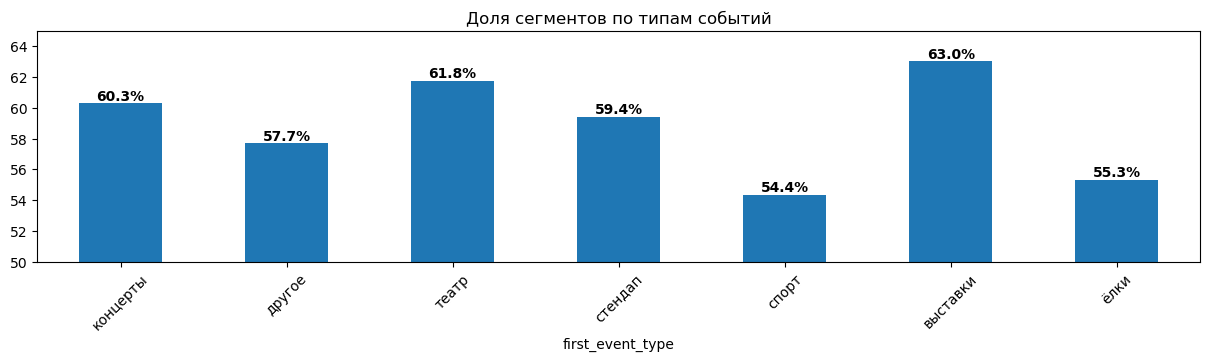

In [21]:
first = pd.DataFrame(group_corr.groupby(['first_event_type']).agg({'first_order': 'count', 'is_2': 'count'}).sort_values(by='first_order', ascending=False))
first['split'] = round((first['is_2'] / first['first_order'])*100,2)
first = first.reset_index()
first.columns = ['first_event_type','first_order','is_2','split']
ax = first.plot(kind='bar', x='first_event_type', y='split', figsize=(15, 3), legend=False)
plt.ylim(50, 65) 
for i, v in enumerate(first['split']):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Доля сегментов по типам событий')
plt.xticks(rotation=45)
plt.show()


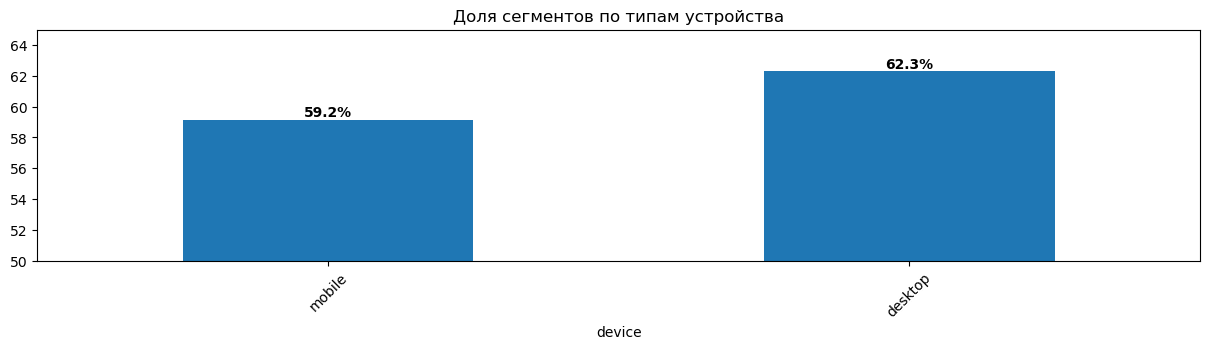

In [22]:
second = group_corr.groupby(['device']).agg({'first_order': 'count','is_2': 'count'}).sort_values(by='first_order', ascending=False)
second['split'] = round((second['is_2'] / second['first_order'])*100,2)
second = second.reset_index()
second.columns = ['device','first_order','is_2','split']
ax = second.plot(kind='bar', x='device', y='split', figsize=(15, 3), legend=False)
plt.ylim(50, 65) 
for i, v in enumerate(second['split']):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Доля сегментов по типам устройства')
plt.xticks(rotation=45)
plt.show()

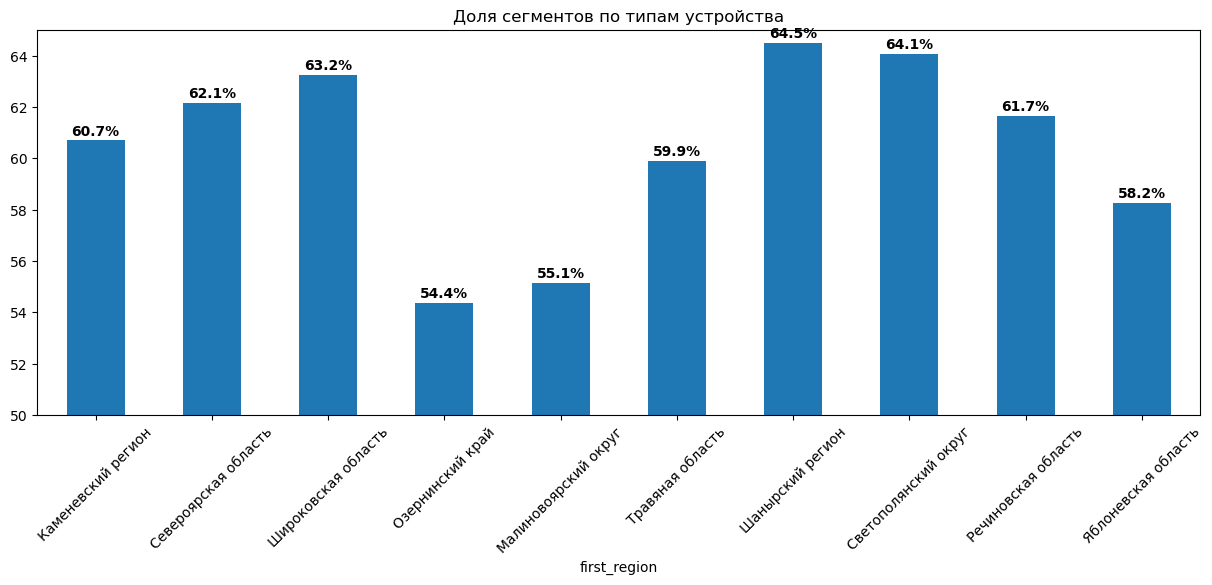

In [23]:
three = group_corr.groupby(['first_region']).agg({'first_order': 'count', 'is_2': 'count'}).sort_values(by='first_order', ascending=False)
three['split'] = round((three['is_2'] / three['first_order'])*100,2)
three = three.reset_index()
three = three.head(10)
three.columns = ['first_region','first_order','is_2','split']
ax = three.plot(kind='bar', x='first_region', y='split', figsize=(15, 5), legend=False)
plt.ylim(50, 65) 
for i, v in enumerate(three['split']):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Доля сегментов по типам устройства')
plt.xticks(rotation=45)
plt.show()

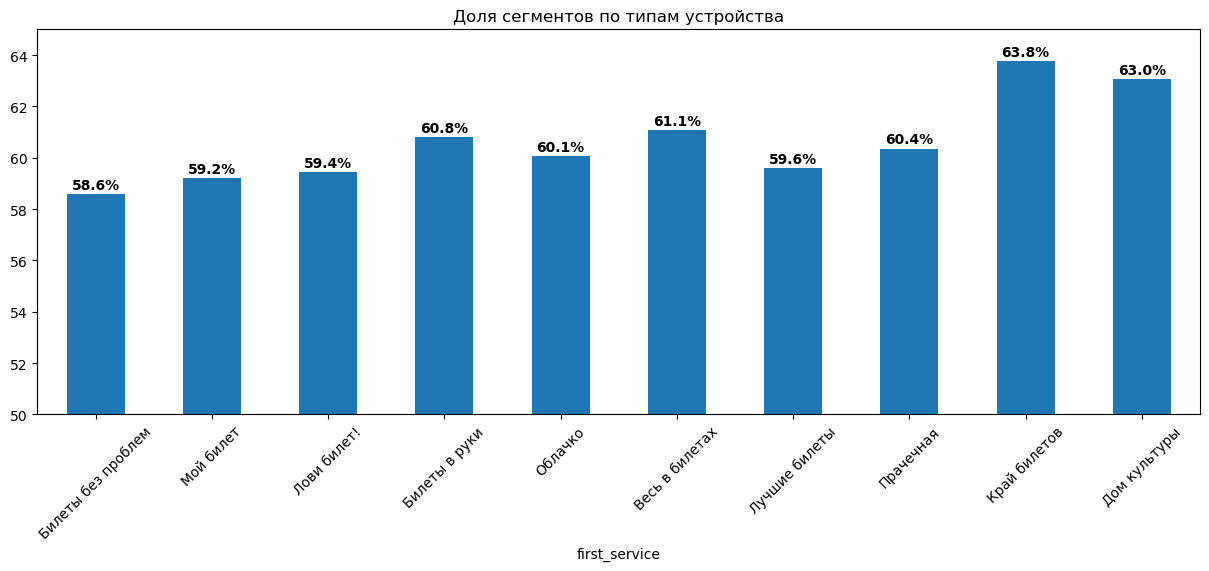

In [24]:
four = group_corr.groupby(['first_service']).agg({'first_order': 'count', 'is_2': 'count'}).sort_values(by='first_order', ascending=False)
four['split'] = round((four['is_2'] / four['first_order'])*100,2)
four = four.reset_index()
four = four.head(10)
four.columns = ['first_service','first_order','is_2','split']
ax = four.plot(kind='bar', x='first_service', y='split', figsize=(15, 5), legend=False)
plt.ylim(50, 65) 
for i, v in enumerate(four['split']):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Доля сегментов по типам устройства')
plt.xticks(rotation=45)
plt.show()

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [25]:
first.query("first_event_type in ('концерты', 'спорт')")[['first_event_type','first_order', 'split']]

,first_event_type,first_order,split
0,концерты,9185,60.30
4,спорт,769,54.36


Данные показывают, что доля повторных заказов у пользователей, чей первый заказ был связан со спортивными мероприятиями, составляет 54.4%, что ниже аналогичного показателя для категории «Концерты» (60.3%). Таким образом, вход через спортивные мероприятия не обеспечивает более высокую лояльность клиентов по сравнению с концертами
При этом кол-во пользователей значительно ниже

In [26]:
three = group_corr.groupby(['first_region']).agg({'first_order': 'count', 'is_2': 'count'}).sort_values(by='first_order', ascending=False)
three['split'] = round((three['is_2'] / three['first_order'])*100,2)
three = three.reset_index()
three.head(10)

,first_region,first_order,is_2,split
0,Каменевский регион,6779,4115,60.70
1,Североярская область,3601,2238,62.15
2,Широковская область,1181,747,63.25
3,Озернинский край,662,360,54.38
4,Малиновоярский округ,515,284,55.15
5,Травяная область,469,281,59.91
6,Шанырский регион,462,298,64.50
7,Светополянский округ,437,280,64.07
8,Речиновская область,420,259,61.67
9,Яблоневская область,400,233,58.25


Несмотря на лидерство по количеству заказов, крупнейшие регионы уступают по доле возврата менее активным Шанырскому и Светополянскому округам. Таким образом, высокая концентрация пользователей в регионе не гарантирует автоматического роста частоты повторных покупок.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


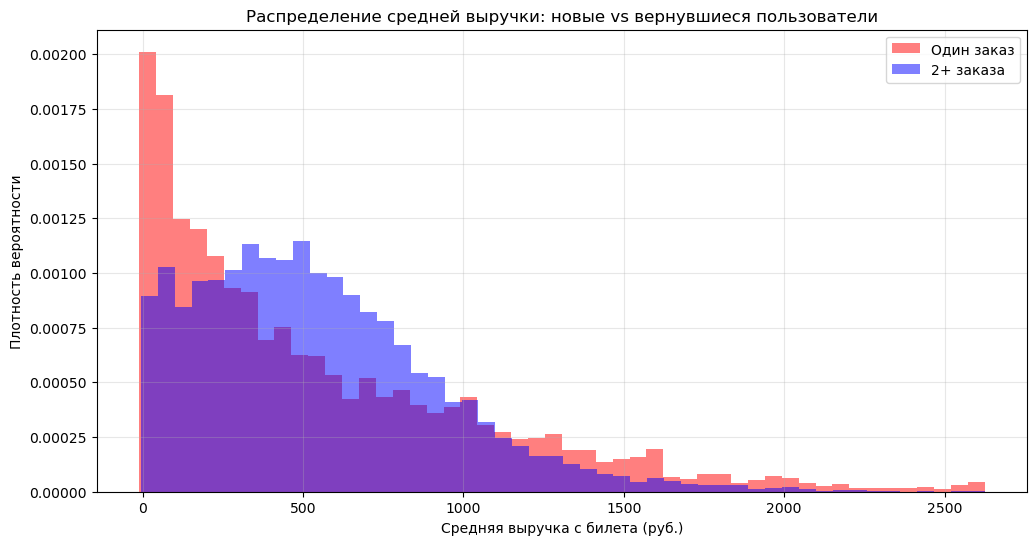

In [27]:
single_order = group_corr.query('orders_count == 1')['avg_revenue']
returning_users = group_corr.query('orders_count >= 2')['avg_revenue']
plt.figure(figsize=(12, 6))
plt.hist(single_order, bins=50, alpha=0.5, label='Один заказ', density=True, color='red')
plt.hist(returning_users, bins=50, alpha=0.5, label='2+ заказа', density=True, color='blue')
plt.title('Распределение средней выручки: новые vs вернувшиеся пользователи')
plt.xlabel('Средняя выручка с билета (руб.)')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Пользователи с одним заказом (красный цвет): Основная масса концентрируется в диапазоне от 0 до 300 рублей. Пик (мода) находится очень близко к нулю, что говорит о том, что новички чаще всего совершают пробную покупку на минимальные суммы.

Вернувшиеся пользователи (синий цвет): Концентрация смещена вправо, основной диапазон — от 300 до 800 рублей. Пик распределения находится в районе 500 рублей.

Смещение ценности: Распределение вернувшихся пользователей (2+ заказа) явно сдвинуто вправо относительно новых пользователей. Это означает, что лояльные клиенты тратят за один раз в среднем больше, чем новички.

Характер трат: У группы с одним заказом наблюдается резкий спад после минимальных чеков. У вернувшихся пользователей распределение более «куполообразное» и пологое, что свидетельствует о готовности покупать билеты в более дорогом сегменте.

Пересечение: В зоне высоких чеков (свыше 1500 рублей) группы практически сравниваются, однако в массовом сегменте (до 1000 рублей) вернувшиеся пользователи показывают более качественный (высокий) средний чек.

Повторные заказы напрямую связаны с ростом средней выручки. Пользователь, возвращающийся в сервис, становится более «дорогим» и выгодным для компании клиентом.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


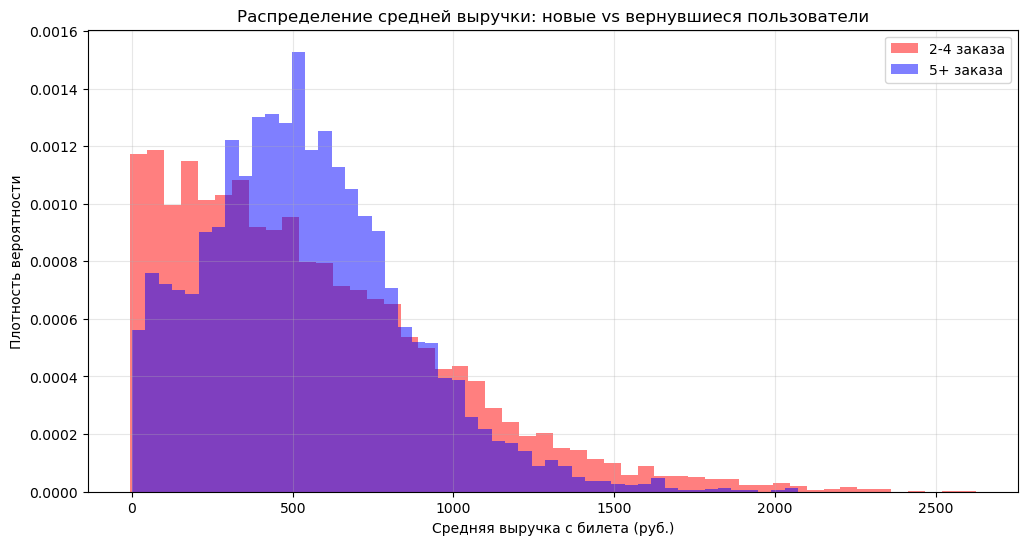

In [28]:
single_order = group_corr.query('orders_count >=2 and orders_count <=4')['avg_revenue']
returning_users = group_corr.query('orders_count >= 5')['avg_revenue']
plt.figure(figsize=(12, 6))
plt.hist(single_order, bins=50, alpha=0.5, label='2-4 заказа', density=True, color='red')
plt.hist(returning_users, bins=50, alpha=0.5, label='5+ заказа', density=True, color='blue')
plt.title('Распределение средней выручки: новые vs вернувшиеся пользователи')
plt.xlabel('Средняя выручка с билета (руб.)')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Группа 2–4 заказа (красная): Пик распределения находится в диапазоне от 0 до 350 рублей. Это значит, что среди умеренно активных пользователей всё ещё много тех, кто выбирает бюджетные билеты.

Группа 5+ заказов (синяя): Пик явно смещен вправо и концентрируется в районе 500–600 рублей. Самые лояльные пользователи совершают «средние» по цене покупки гораздо чаще.

У «синей» группы (5+ заказов) плотность в зоне самых низких чеков (до 250 рублей) заметно ниже, чем у «красной». Это говорит о том, что опытные пользователи реже совершают покупки в самом дешевом сегменте.

Начиная с отметки 1000 рублей и выше, графики практически накладываются друг на друга. Это означает, что доля «дорогих» заказов в обеих группах примерно одинакова.

Различие есть. Группа «5+ заказов» более однородна в своих тратах (высокий узкий пик) и ориентирована на средний ценовой сегмент, в то время как группа «2–4 заказа» более склонна к дешевым билетам, что роднит её поведение с новичками.


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [29]:
group_corr = group_corr.copy()
bins = [1, 2, 3, 5, float('inf')]
labels = ['от 1 до 2 билетов', 'от 2 до 3 билетов', 'от 3 до 5 билетов', 'от 5 и более билетов']
group_corr['ticket_segment'] = pd.cut(group_corr['avg_tickets'], bins=bins, labels=labels, include_lowest=True)
group_corr['is_returning'] = np.where(group_corr['avg_gap'].notna(), 1, 0)
analysis = group_corr.groupby('ticket_segment', observed=False).agg(
    total_users=('is_returning', 'count'),
    returning_users=('is_returning', 'sum')
)
analysis['retention_rate'] = round((analysis['returning_users'] / analysis['total_users']) * 100, 2)
analysis


,total_users,returning_users,retention_rate
ticket_segment,,,
от 1 до 2 билетов,6159,2486,40.36
от 2 до 3 билетов,9169,6632,72.33
от 3 до 5 билетов,5233,3243,61.97
от 5 и более билетов,194,64,32.99


Анализ показал, что аудитория сервиса крайне неоднородна: основной объем заказов (около 44%) генерирует сегмент «от 2 до 3 билетов», в то время как крупные групповые покупки (5+ билетов) составляют менее 1% выборки.

Данный сегмент («2–3 билета») является наиболее ценным для бизнеса, так как демонстрирует рекордную долю возврата — 72,33%, что значительно выше показателей «одиночек» (40,36%) и организаторов больших групп (32,99%). 

Таким образом, совместные походы на мероприятия небольшими компаниями являются главным драйвером удержания пользователей на платформе.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [30]:
group_corr['day_name'] = group_corr['first_order'].dt.day_name()
day_name = group_corr.groupby('day_name').agg({'first_order': 'count','avg_gap': 'count'})
day_name = day_name.reset_index()
day_name['percentil'] = round(day_name['avg_gap'] / day_name['first_order']*100,2)
days_map = {
    'Monday': 'Понедельник', 'Tuesday': 'Вторник', 'Wednesday': 'Среда',
    'Thursday': 'Четверг', 'Friday': 'Пятница', 'Saturday': 'Суббота', 'Sunday': 'Воскресенье'
}
days_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
day_name['day_name'] = day_name['day_name'].map(days_map)
day_name['day_name'] = pd.Categorical(day_name['day_name'], categories=days_order, ordered=True)
day_name = day_name.sort_values('day_name')
day_name

,day_name,first_order,avg_gap,percentil
1,Понедельник,2821,1745,61.86
5,Вторник,3015,1818,60.30
6,Среда,2960,1806,61.01
4,Четверг,3028,1768,58.39
0,Пятница,3167,1865,58.89
2,Суббота,3123,1887,60.42
3,Воскресенье,2641,1536,58.16


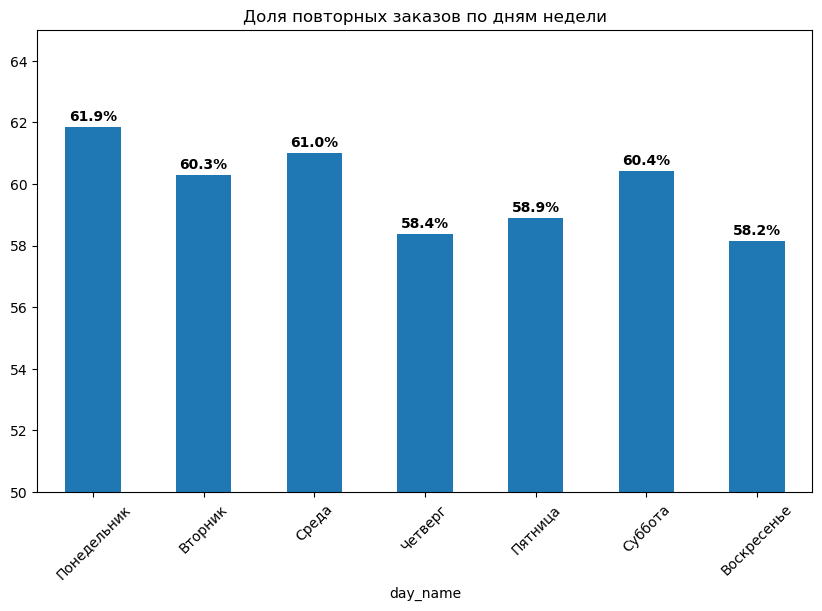

In [31]:
ax = day_name.plot(kind='bar', x='day_name', y='percentil', figsize=(10, 6), legend=False)
plt.ylim(50, 65)
for i, v in enumerate(day_name['percentil']):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Доля повторных заказов по дням недели')
plt.xticks(rotation=45)
plt.show()


Разница между лучшим (Понедельник) и худшим (Воскресенье) днем составляет 3.7 процентных пункта. Это значимый показатель для бизнеса, подтверждающий, что клиенты, начинающие знакомство с сервисом в начале недели, в среднем более перспективны для долгосрочного удержания.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [32]:
group_corr = group_corr.reset_index()
bins = [2, 5, float('inf')]
labels = ['совершившие 2-4 заказа', 'совершившие 5 и более заказов']
group_corr['order_segment'] = pd.cut(group_corr['orders_count'], bins=bins, labels=labels, right=False)
analysis_gap = group_corr.groupby('order_segment', observed=False).agg({
    'avg_gap': 'mean',
    'user_id': 'count' # чтобы видеть размер выборки
})
analysis_gap['avg_gap'] = analysis_gap['avg_gap'].round(2)
analysis_gap


,avg_gap,user_id
order_segment,,
совершившие 2-4 заказа,21.32,7146
совершившие 5 и более заказов,11.13,5244


Между частотой покупок и удержанием клиентов наблюдается прямая зависимость: чем короче интервал между заказами, тем выше вероятность того, что пользователь станет супер-лояльным (категория 5+). 

Среднее время возврата у наиболее активных клиентов составляет всего 11 дней, что почти в два раза меньше, чем у группы с 2–4 заказами (21 день). 

Таким образом, высокая интенсивность взаимодействий с сервисом на ранних этапах является ключевым индикатором формирования долгосрочной привычки использования платформы.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [33]:
correlation_matrix = group_corr.phik_matrix(interval_cols = ['orders_count', 'avg_revenue', 'avg_tickets', 'avg_gap', 'is_returning'])
order_corr = correlation_matrix[['orders_count']].sort_values( by='orders_count', ascending=False)
order_corr

C:\Users\Admin\anaconda3\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable user_id is large: 20755. Are you sure this is not an interval variable? Analysis for pairs of variables including user_id can be slow.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable is_2 for analysis 1. Dropping this column
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable is_5 for analysis 1. Dropping this column
  warnings.warn(


,orders_count
user_id,1.000000
orders_count,1.000000
order_segment,0.975744
is_returning,0.717830
avg_gap,0.490347
last_order,0.399368
first_order,0.398297
avg_tickets,0.296703
ticket_segment,0.278172
avg_revenue,0.266508


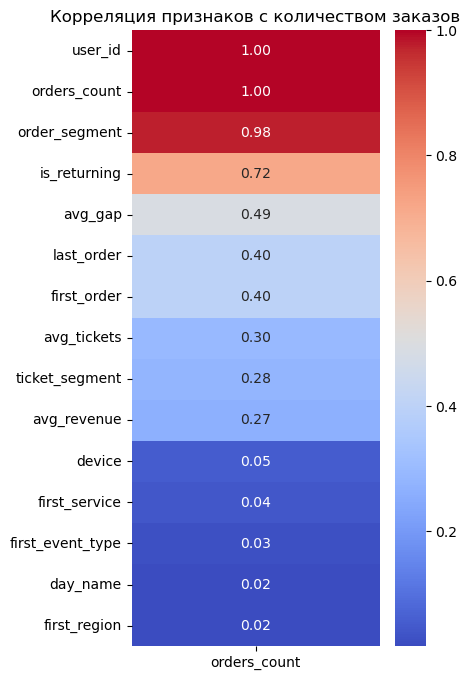

In [34]:
plt.figure(figsize=(4, 8))
sns.heatmap(order_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков с количеством заказов')
plt.show()

In [35]:
group_corr = group_corr.copy()
bins = [1,2,5, float('inf')]
labels = ['1 заказ','2-4 заказа','5 и более заказов']
group_corr['segment'] = pd.cut(group_corr['orders_count'], bins=bins, labels=labels, right=False)

In [36]:
correlation_matrix = group_corr.phik_matrix(interval_cols = ['orders_count', 'avg_revenue', 'avg_tickets', 'avg_gap', 'is_returning'])
order_corr = correlation_matrix[['segment']].sort_values( by='segment', ascending=False)
order_corr

C:\Users\Admin\anaconda3\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable user_id is large: 20755. Are you sure this is not an interval variable? Analysis for pairs of variables including user_id can be slow.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable is_2 for analysis 1. Dropping this column
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable is_5 for analysis 1. Dropping this column
  warnings.warn(


,segment
user_id,1.000000
segment,1.000000
order_segment,0.896695
is_returning,0.836626
orders_count,0.776406
last_order,0.559871
first_order,0.524562
avg_gap,0.378317
avg_tickets,0.358584
avg_revenue,0.299893


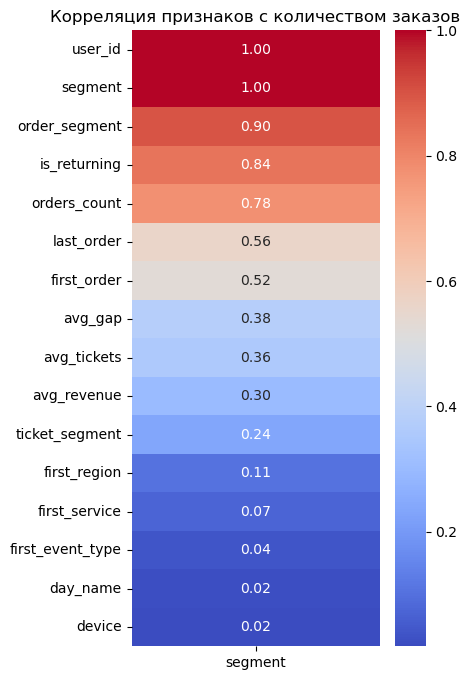

In [37]:
plt.figure(figsize=(4, 8))
sns.heatmap(order_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков с количеством заказов')
plt.show()

Анализ матрицы корреляции показывает, что количество заказов наиболее тесно связано с поведенческими характеристиками пользователя и его «временем жизни» в сервисе. 

Самые высокие коэффициенты наблюдаются у сегментационных признаков и факта возврата, что подтверждает прямую зависимость этих метрик от накопленной истории покупок. 

Значительное влияние на итоговый результат оказывают даты первого и последнего заказов, подчеркивая важность длительного удержания клиента на платформе. 

Умеренная связь с интервалом между покупками доказывает, что интенсивность визитов напрямую конвертируется в общее число совершенных сделок. 

Количество билетов в чеке также коррелирует с лояльностью, указывая на то, что пользователи, покупающие билеты на несколько человек, чаще возвращаются в сервис. 

При этом технические и географические параметры, такие как тип устройства, день недели или регион, практически не влияют на формирование долгосрочной привычки у клиента. 

Таким образом, для роста числа заказов бизнесу следует фокусироваться на стимулировании частоты повторных покупок и сокращении времени между ними, а не на технических условиях первого входа.

Исследование выявило ключевые факторы, влияющие на возврат пользователей:

1. Точки входа пользователей
- Основной канал привлечения — концерты;
- Большинство пользователей приходит с мобильных устройств;
- Наблюдается сильная концентрация в отдельных регионах и сервисах.

Таким образом, существует чёткий портрет «типичного нового пользователя».

2. Возврат пользователей
- Не все популярные сегменты обеспечивают высокий возврат;
- Гипотеза о превосходстве спортивных мероприятий по удержанию не подтвердилась;
- Высокая активность региона не гарантирует высокую лояльность.

3. Финансовое поведение
- Вернувшиеся пользователи тратят больше;
- С ростом числа заказов увеличивается средний чек;
- Лояльные пользователи ориентируются на средний ценовой сегмент.

4. Поведение при покупке билетов
- Наиболее ценный сегмент — пользователи, покупающие 2–3 билета;
- Именно они демонстрируют максимальную вероятность возврата;
- Крупные групповые покупки не связаны с высокой лояльностью.

Общий вывод

Лояльность пользователей тесно связана с их вовлечённостью: чем выше средний чек и более «социальный» формат потребления (небольшие компании), тем выше вероятность повторных покупок.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

В рамках проекта был проведён анализ пользовательских данных сервиса, включающих информацию о заказах, пользователях и характеристиках мероприятий. После загрузки данные были подготовлены: выполнена очистка, обработка пропусков, приведение типов, а также конвертация выручки в рубли. Для повышения качества анализа были отфильтрованы выбросы (по выручке и активности пользователей), что позволило сосредоточиться на типичном поведении аудитории.

В итоговой выборке представлено значительное количество пользователей, при этом распределение по числу заказов имеет выраженный дисбаланс: большинство пользователей совершает один заказ, доля повторных покупок существенно ниже, а высокоактивные пользователи составляют малую часть аудитории. Были рассчитаны ключевые метрики, включая среднюю выручку, количество билетов, частоту покупок и интервалы между заказами.

Анализ показал, что на возврат пользователей влияют характеристики первого заказа. Наиболее значимыми факторами являются:

- тип события (развлекательные мероприятия, особенно концерты, чаще приводят к повторным покупкам);
- количество билетов (наиболее лояльны пользователи, покупающие 2–3 билета);
- средний чек (более высокая выручка связана с большей вероятностью возврата);
- канал и устройство входа (мобильные пользователи демонстрируют более высокую вовлечённость).

Также выявлена связь между финансовым поведением и лояльностью: пользователи с более высоким средним чеком и умеренным количеством билетов чаще возвращаются. При этом слишком большие заказы (много билетов) не коррелируют с высокой вероятностью повторных покупок.

Временные характеристики также оказывают влияние: более короткие интервалы между покупками связаны с большей вероятностью удержания, а отдельные дни недели могут демонстрировать различия в активности и возврате пользователей.

Корреляционный анализ показал, что с числом покупок связаны такие признаки, как частота заказов, средняя выручка, количество билетов и интервалы между покупками. Это подтверждает, что лояльность формируется через регулярность и вовлечённость пользователя.

Рекомендации заказчику
1. Сфокусироваться на сегменте пользователей с 2–3 билетами в заказе
Это наиболее перспективная аудитория с точки зрения возврата. Для неё можно разрабатывать специальные предложения и программы лояльности.
2. Развивать сегмент со средним чеком выше среднего
Такие пользователи демонстрируют более высокую вероятность повторных покупок — важно удерживать их через персонализированные рекомендации и бонусы.
3. Усилить работу с пользователями после первого заказа
Так как большая часть аудитории не возвращается, критически важно выстраивать коммуникацию сразу после первой покупки (email-рассылки, push-уведомления, персональные подборки событий).
4. Продвигать наиболее «возвратные» категории событий
Например, концерты и другие популярные форматы, которые чаще формируют повторное поведение.
5. Использовать временные триггеры
Стимулировать повторные покупки в короткие сроки после первого заказа (например, через ограниченные по времени предложения).
6. Персонализировать маркетинг по поведению
Учитывать количество билетов, частоту покупок и средний чек при формировании предложений.

В целом, результаты анализа могут быть использованы для построения моделей прогнозирования оттока и разработки стратегий удержания, направленных на увеличение доли лояльных пользователей и роста выручки сервиса.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**